In [1]:
!pip install wrds

In [3]:
import wrds
import pandas as pd
import matplotlib.pyplot as plt
db = wrds.Connection(
    wrds_username="sitongli24", 
    wrds_password="200504s@200504s@"    
)

Loading library list...
Done


In [75]:
ticker = "AAPL"
start_date = "2021-01-01"

selected_columns = """
b.htsymbol,
b.permno,
a.date,
a.prc,
a.ret
"""

sql_query = f"""
SELECT {selected_columns}
FROM crsp.msf AS a
LEFT JOIN crsp.msfhdr AS b
    ON a.permno = b.permno
WHERE b.htsymbol = '{ticker}'
AND a.date >= '{start_date}'
"""

stock_joined = db.raw_sql(sql_query, date_cols=["date"])

stock_joined = stock_joined.rename(columns={
    "htsymbol": "ticker",
    "prc": "price",
    "ret": "monthly_return"
})

print(stock_joined.columns)
stock_joined.head()

Index(['ticker', 'permno', 'date', 'price', 'monthly_return'], dtype='object')


,ticker,permno,date,price,monthly_return
0,AAPL,14593,2021-01-29,131.96001,-0.005502
1,AAPL,14593,2021-02-26,121.26,-0.079532
2,AAPL,14593,2021-03-31,122.15,0.00734
3,AAPL,14593,2021-04-30,131.46001,0.076218
4,AAPL,14593,2021-05-28,124.61,-0.050434


In [76]:
check_sql = """
SELECT * FROM crsp.msi LIMIT 1
"""
check_df = db.raw_sql(check_sql)
print(check_df.columns)

Index(['date', 'vwretd', 'vwretx', 'ewretd', 'ewretx', 'sprtrn', 'spindx',
       'totval', 'totcnt', 'usdval', 'usdcnt'],
      dtype='object')


In [77]:
start_date = "2021-01-01"

market_sql = f"""
SELECT date, vwretd as market_return
FROM crsp.msi
WHERE date >= '{start_date}'
"""

print(market_sql)

market_data = db.raw_sql(market_sql, date_cols=["date"])

print(market_data.columns)
market_data.head()


SELECT date, vwretd as market_return
FROM crsp.msi
WHERE date >= '2021-01-01'

Index(['date', 'market_return'], dtype='object')


,date,market_return
0,2021-01-29,-0.000631
1,2021-02-26,0.029196
2,2021-03-31,0.030573
3,2021-04-30,0.04819
4,2021-05-28,0.007092


In [78]:
import pandas as pd

combined_data = pd.merge(
    stock_joined,  
    market_data,   
    on="date",     
    how="left"     
)

combined_data = combined_data.dropna(subset=["monthly_return", "market_return"])

print(combined_data.columns)
combined_data.head()

Index(['ticker', 'permno', 'date', 'price', 'monthly_return', 'market_return'], dtype='object')


,ticker,permno,date,price,monthly_return,market_return
0,AAPL,14593,2021-01-29,131.96001,-0.005502,-0.000631
1,AAPL,14593,2021-02-26,121.26,-0.079532,0.029196
2,AAPL,14593,2021-03-31,122.15,0.00734,0.030573
3,AAPL,14593,2021-04-30,131.46001,0.076218,0.04819
4,AAPL,14593,2021-05-28,124.61,-0.050434,0.007092


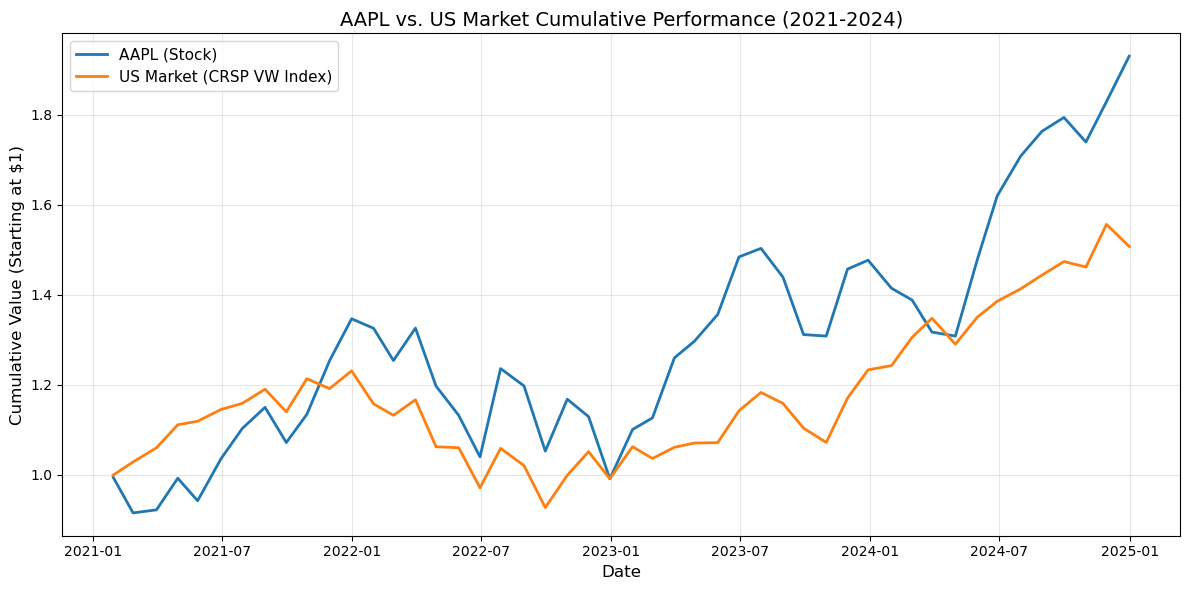

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

if not os.path.exists("acc102_plots"):
    os.makedirs("acc102_plots")

combined_data["stock_nav"] = (1 + combined_data["monthly_return"]).cumprod()
combined_data["market_nav"] = (1 + combined_data["market_return"]).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(combined_data["date"], combined_data["stock_nav"], 
         label=f"{ticker} (Stock)", color="#1f77b4", linewidth=2)
plt.plot(combined_data["date"], combined_data["market_nav"], 
         label="US Market (CRSP VW Index)", color="#ff7f0e", linewidth=2)

plt.title(f"{ticker} vs. US Market Cumulative Performance (2021-2024)", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Cumulative Value (Starting at $1)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(f"acc102_plots/1_{ticker}_cumulative_performance.png", dpi=300, bbox_inches="tight")
plt.show()

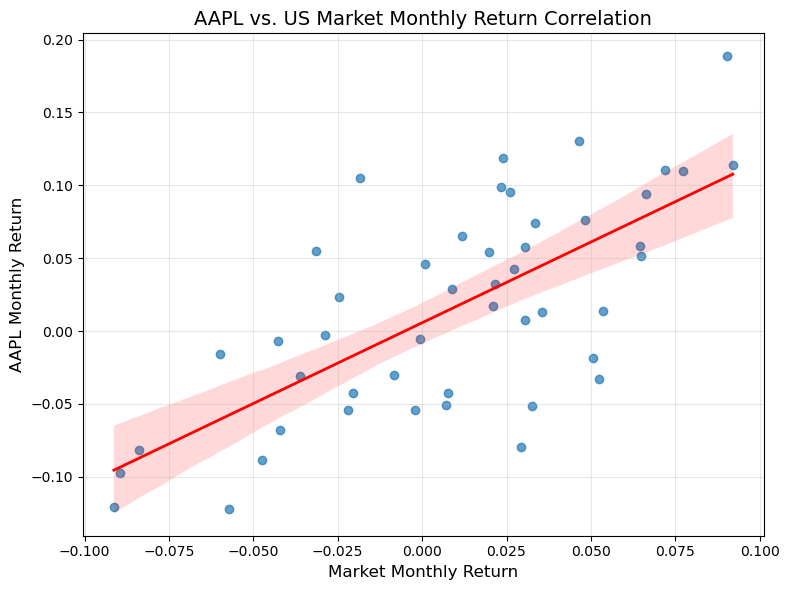

In [80]:
plt.figure(figsize=(8, 6))
sns.regplot(
    x=combined_data["market_return"], 
    y=combined_data["monthly_return"],
    line_kws={"color": "red", "linewidth": 2},
    scatter_kws={"alpha": 0.7, "color": "#1f77b4"}
)
plt.title(f"{ticker} vs. US Market Monthly Return Correlation", fontsize=14)
plt.xlabel("Market Monthly Return", fontsize=12)
plt.ylabel(f"{ticker} Monthly Return", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(f"acc102_plots/2_{ticker}_beta_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

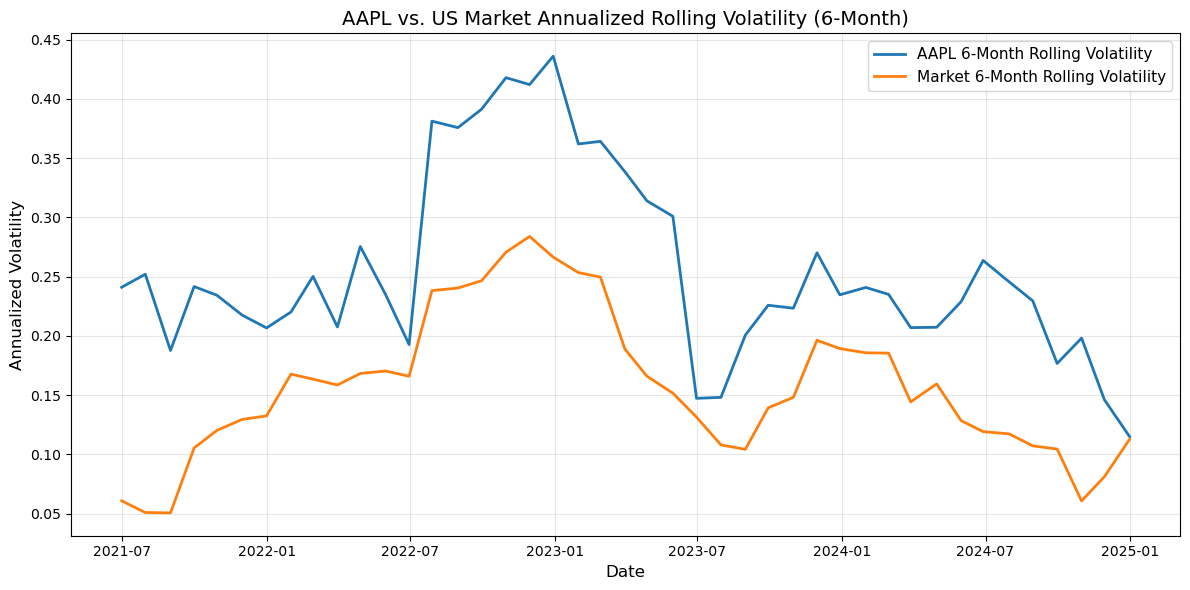

In [81]:
combined_data["stock_vol"] = combined_data["monthly_return"].rolling(6).std() * (12**0.5)
combined_data["market_vol"] = combined_data["market_return"].rolling(6).std() * (12**0.5)

plt.figure(figsize=(12, 6))
plt.plot(combined_data["date"], combined_data["stock_vol"], 
         label=f"{ticker} 6-Month Rolling Volatility", color="#1f77b4", linewidth=2)
plt.plot(combined_data["date"], combined_data["market_vol"], 
         label="Market 6-Month Rolling Volatility", color="#ff7f0e", linewidth=2)

plt.title(f"{ticker} vs. US Market Annualized Rolling Volatility (6-Month)", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Annualized Volatility", fontsize=12)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(f"acc102_plots/3_{ticker}_rolling_volatility.png", dpi=300, bbox_inches="tight")
plt.show()

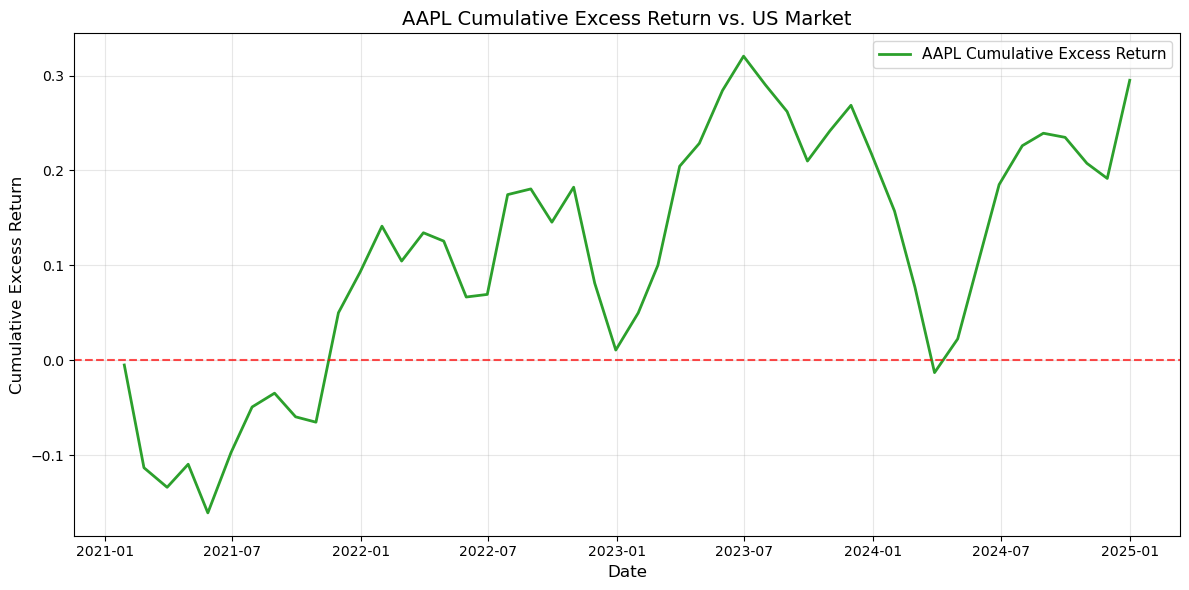

In [82]:
combined_data["excess_return"] = combined_data["monthly_return"] - combined_data["market_return"]
combined_data["cum_excess_return"] = (1 + combined_data["excess_return"]).cumprod() - 1

plt.figure(figsize=(12, 6))
plt.plot(combined_data["date"], combined_data["cum_excess_return"], 
         label=f"{ticker} Cumulative Excess Return", color="#2ca02c", linewidth=2)
plt.axhline(y=0, color="red", linestyle="--", alpha=0.7)

plt.title(f"{ticker} Cumulative Excess Return vs. US Market", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Cumulative Excess Return", fontsize=12)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(f"acc102_plots/4_{ticker}_excess_return.png", dpi=300, bbox_inches="tight")
plt.show()

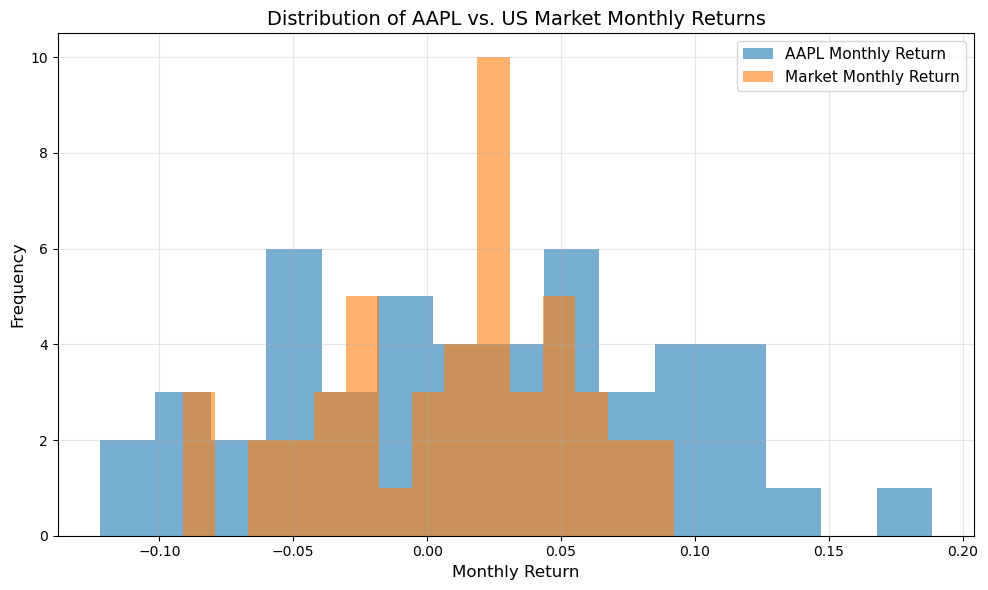

In [83]:
plt.figure(figsize=(10, 6))
plt.hist(combined_data["monthly_return"], bins=15, alpha=0.6, 
         label=f"{ticker} Monthly Return", color="#1f77b4")
plt.hist(combined_data["market_return"], bins=15, alpha=0.6, 
         label="Market Monthly Return", color="#ff7f0e")

plt.title(f"Distribution of {ticker} vs. US Market Monthly Returns", fontsize=14)
plt.xlabel("Monthly Return", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(f"acc102_plots/5_{ticker}_return_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

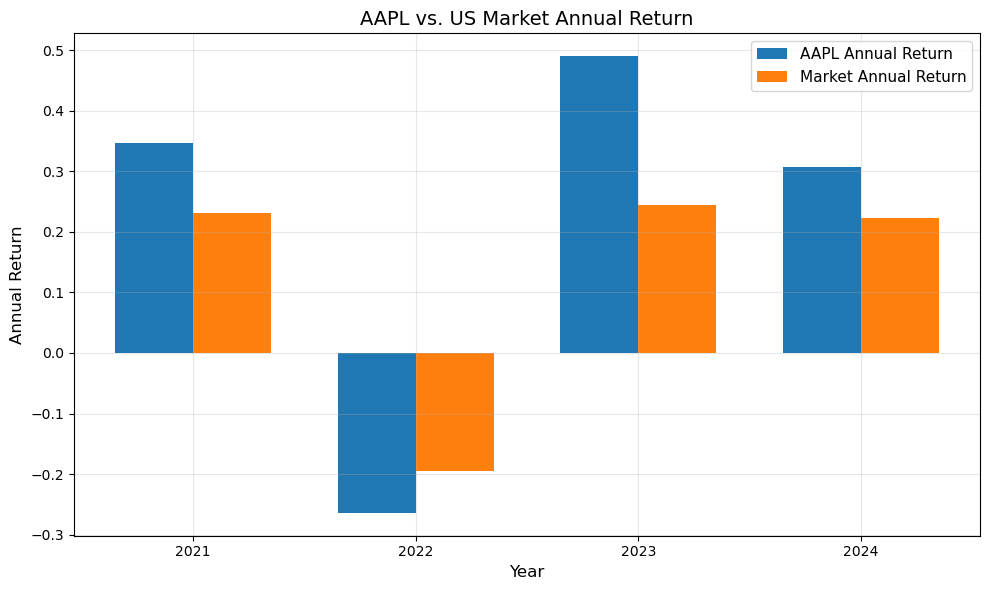

In [84]:
combined_data["year"] = combined_data["date"].dt.year
annual_data = combined_data.groupby("year").agg({
    "monthly_return": lambda x: (1 + x).prod() - 1,
    "market_return": lambda x: (1 + x).prod() - 1
}).reset_index()

plt.figure(figsize=(10, 6))
x = range(len(annual_data))
width = 0.35

plt.bar([i - width/2 for i in x], annual_data["monthly_return"], 
        width=width, label=f"{ticker} Annual Return", color="#1f77b4")
plt.bar([i + width/2 for i in x], annual_data["market_return"], 
        width=width, label="Market Annual Return", color="#ff7f0e")

plt.xticks(x, annual_data["year"])
plt.title(f"{ticker} vs. US Market Annual Return", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Annual Return", fontsize=12)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(f"acc102_plots/6_{ticker}_annual_return.png", dpi=300, bbox_inches="tight")
plt.show()